In [1]:
import numpy as np
import pandas as pd

In [2]:
data_ses = pd.read_csv("../Output/Pred Input/SES_train.csv")

X_ses = data_ses.drop(columns=['LSOA21CD'])

In [3]:
import torch

y = torch.load("../Output/Pred Input/y_train_5.pt")
y = y.numpy()

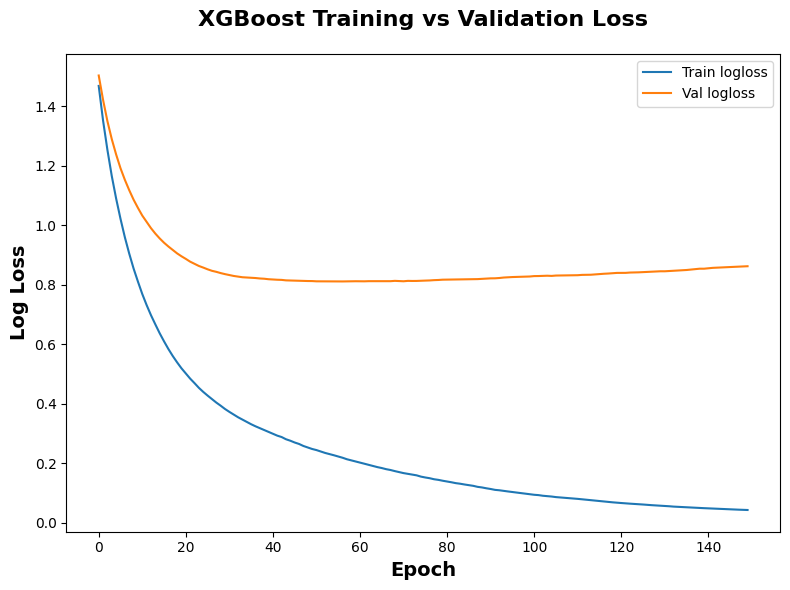

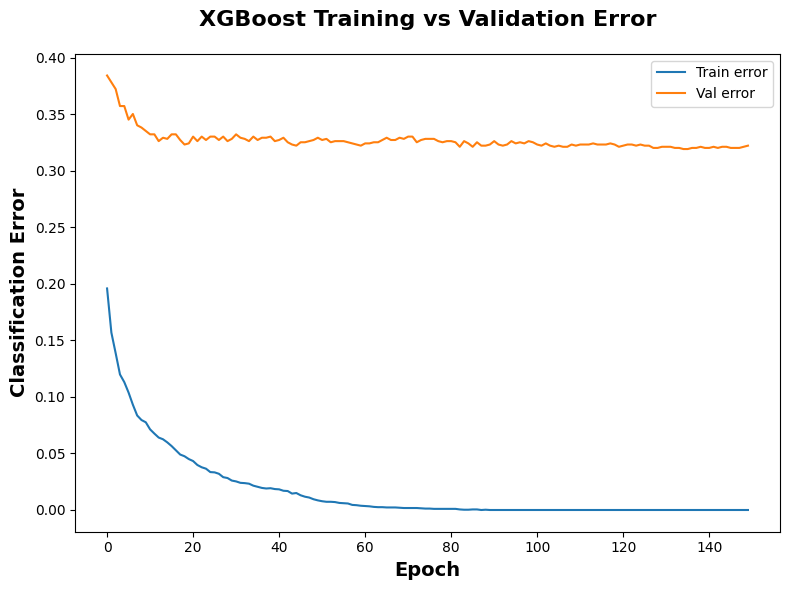

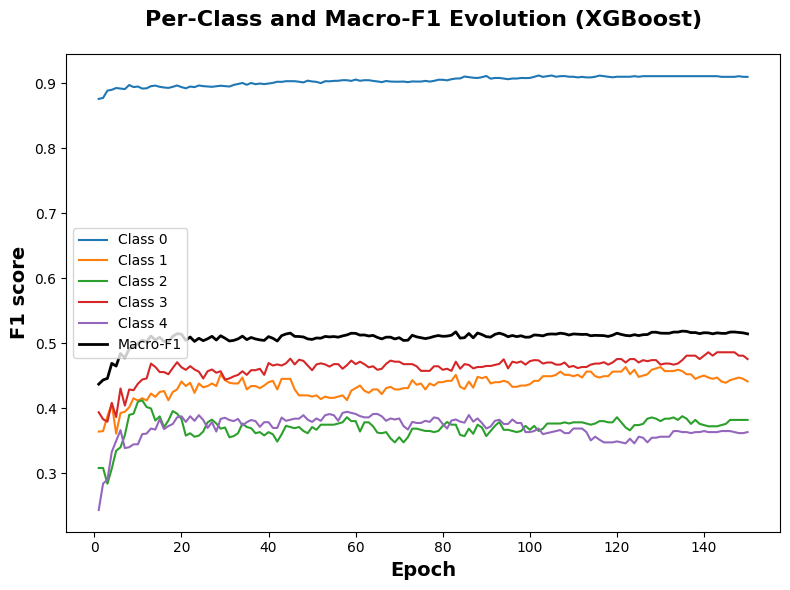

In [6]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from xgboost import XGBClassifier
import os

# === Output dirs ===
os.makedirs("../Output/Performance", exist_ok=True)
os.makedirs("../Output/Figures", exist_ok=True)

# === 1) Data split ===

X_tr, X_va, y_tr, y_va = train_test_split(
    X_ses, y, test_size=0.2, stratify=y, random_state=42
)

num_classes = np.unique(y).size

# === 2) Model training ===
xgb = XGBClassifier(
    objective="multi:softprob",
    num_class=num_classes,
    learning_rate=0.1,
    max_depth=7,
    n_estimators=150,
    random_state=42,
    eval_metric=["mlogloss", "merror"],   # XGB internal metrics
)

xgb.fit(X_tr, y_tr, eval_set=[(X_tr, y_tr), (X_va, y_va)], verbose=False)

# === 3) Collect training history ===
hist = xgb.evals_result()

# ---- Plot loss curves ----
plt.figure(figsize=(8,6))
plt.plot(hist["validation_0"]["mlogloss"], label="Train logloss")
plt.plot(hist["validation_1"]["mlogloss"], label="Val logloss")
plt.xlabel("Epoch", fontsize=14, fontweight='bold')
plt.ylabel("Log Loss", fontsize=14, fontweight='bold')
plt.title("XGBoost Training vs Validation Loss", fontsize=16, fontweight='bold',pad=20)
plt.legend()
plt.tight_layout()
plt.savefig("../Output/Figures/xgb_loss_curve.png", dpi=300)
plt.show()

plt.figure(figsize=(8,6))
plt.plot(hist["validation_0"]["merror"], label="Train error")
plt.plot(hist["validation_1"]["merror"], label="Val error")
plt.xlabel("Epoch", fontsize=14, fontweight='bold')
plt.ylabel("Classification Error", fontsize=14, fontweight='bold')
plt.title("XGBoost Training vs Validation Error", fontsize=16, fontweight='bold',pad=20)
plt.legend()
plt.tight_layout()
plt.savefig("../Output/Figures/xgb_error_curve.png", dpi=300)
plt.show()

# === 4) Compute per-class F1 at each epoch ===
epochs = range(1, xgb.n_estimators + 1)
f1_per_class = {cls: [] for cls in range(num_classes)}
f1_macro = []

for i in epochs:
    y_proba = xgb.predict_proba(X_va, iteration_range=(0, i))
    y_pred = np.argmax(y_proba, axis=1)
    f1_scores = f1_score(y_va, y_pred, average=None, labels=np.arange(num_classes), zero_division=0)
    for cls in range(num_classes):
        f1_per_class[cls].append(f1_scores[cls])
    f1_macro.append(f1_score(y_va, y_pred, average="macro", zero_division=0))

# Save to CSV
df_f1 = pd.DataFrame({"epoch": epochs, "macro_F1": f1_macro})
for cls in range(num_classes):
    df_f1[f"F1_class{cls}"] = f1_per_class[cls]
df_f1.to_csv("../Output/Performance/xgb_f1_per_class.csv", index=False)

# === 5) Plot F1 curves ===
plt.figure(figsize=(8,6))
for cls in range(num_classes):
    plt.plot(df_f1["epoch"], df_f1[f"F1_class{cls}"], label=f"Class {cls}")
plt.plot(df_f1["epoch"], df_f1["macro_F1"], color="black", linewidth=2.0, label="Macro-F1")
plt.xlabel("Epoch", fontsize=14, fontweight='bold')
plt.ylabel("F1 score", fontsize=14, fontweight='bold')
plt.title("Per-Class and Macro-F1 Evolution (XGBoost)", fontsize=16, fontweight='bold',pad=20)
plt.legend()
plt.tight_layout()
plt.savefig("../Output/Figures/xgb_f1_per_class.png", dpi=300)
plt.show()